# 🦺 Hard Hat Detection with YOLOv8

Detect in an image:
- **helmet** — worker wearing a hard hat
- **head** — head without a hard hat (unsafe ⚠️)
- **person**

**Dataset:** Hard Hat Detection – Kaggle (`andrewmvd/hard-hat-detection`), Pascal VOC format → converted to YOLO format.

Run the cells top to bottom.

## 1) Setup

In [2]:
!pip install ultralytics --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.1 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO
import ultralytics
ultralytics.checks()

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.1/112.6 GB disk)


## 2) Download dataset from Kaggle

Upload your `kaggle.json` (Kaggle → Account → Create New API Token) next to this notebook first.
If you downloaded the dataset manually, skip this and edit the paths in section 4.

In [4]:
!pip install kaggle --quiet
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d andrewmvd/hard-hat-detection
!unzip -q hard-hat-detection.zip -d hardhat
!ls hardhat

cp: cannot stat 'kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/hard-hat-detection
License(s): CC0-1.0
100% 1.22G/1.22G [00:11<00:00, 117MB/s] 

annotations  images


## 3) VOC → YOLO format

**Pascal VOC** (source): one XML per image, corner pixels `xmin, ymin, xmax, ymax`.

**YOLO** (target): one `.txt` per image, one box per line, values normalized to 0–1:
```
class_id  x_center  y_center  width  height
```
```
x_center = ((xmin + xmax) / 2) / image_width
y_center = ((ymin + ymax) / 2) / image_height
width    = (xmax - xmin) / image_width
height   = (ymax - ymin) / image_height
```

## 4) Convert annotations + split (80/10/10)

`classes` order defines each class id and must match `names` in `data.yaml`.

In [5]:
import os, glob, shutil, random
import xml.etree.ElementTree as ET
from pathlib import Path

SRC_IMAGES = "hardhat/images"
SRC_ANNOTS = "hardhat/annotations"

OUT = "dataset"
classes = ["helmet", "head", "person"]   # helmet=0, head=1, person=2

for split in ["train", "val", "test"]:
    os.makedirs(f"{OUT}/images/{split}", exist_ok=True)
    os.makedirs(f"{OUT}/labels/{split}", exist_ok=True)

def convert_one(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    w = int(root.find("size/width").text)
    h = int(root.find("size/height").text)
    lines = []
    for obj in root.findall("object"):
        name = obj.find("name").text
        if name not in classes:
            continue
        cls_id = classes.index(name)
        b = obj.find("bndbox")
        xmin = float(b.find("xmin").text); ymin = float(b.find("ymin").text)
        xmax = float(b.find("xmax").text); ymax = float(b.find("ymax").text)
        xc = ((xmin + xmax) / 2) / w
        yc = ((ymin + ymax) / 2) / h
        bw = (xmax - xmin) / w
        bh = (ymax - ymin) / h
        lines.append(f"{cls_id} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")
    return lines

xml_files = glob.glob(f"{SRC_ANNOTS}/*.xml")
random.seed(42)
random.shuffle(xml_files)

n = len(xml_files)
n_train = int(0.8 * n)
n_val   = int(0.1 * n)

splits = {
    "train": xml_files[:n_train],
    "val":   xml_files[n_train:n_train + n_val],
    "test":  xml_files[n_train + n_val:],
}

missing = 0
for split, files in splits.items():
    for xml_path in files:
        stem = Path(xml_path).stem
        img_src = f"{SRC_IMAGES}/{stem}.png"
        if not os.path.exists(img_src):
            missing += 1
            continue
        shutil.copy(img_src, f"{OUT}/images/{split}/{stem}.png")
        with open(f"{OUT}/labels/{split}/{stem}.txt", "w") as f:
            f.write("\n".join(convert_one(xml_path)))

print("Done. total:", n, "| train:", len(splits['train']),
      "| val:", len(splits['val']), "| test:", len(splits['test']))
if missing:
    print("missing images:", missing)

Done. total: 5000 | train: 4000 | val: 500 | test: 500


## 5) Sanity check — draw boxes on a random sample

If boxes land correctly, the conversion is good.

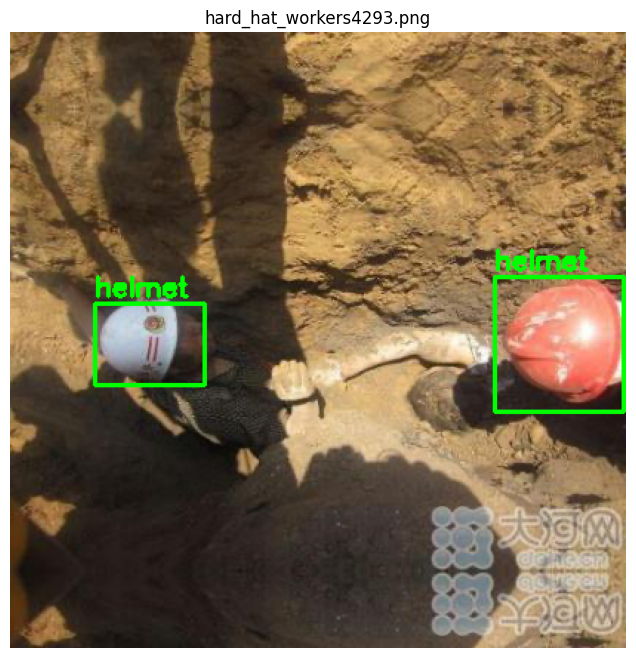

In [6]:
import cv2, glob, random
import matplotlib.pyplot as plt

colors = {0: (0,255,0), 1: (255,0,0), 2: (0,0,255)}
names  = {0: "helmet", 1: "head", 2: "person"}

img_path = random.choice(glob.glob(f"{OUT}/images/train/*.png"))
lbl_path = img_path.replace("images", "labels").replace(".png", ".txt")

img = cv2.imread(img_path); img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
H, W = img.shape[:2]

with open(lbl_path) as f:
    for line in f.read().splitlines():
        c, xc, yc, bw, bh = map(float, line.split()); c = int(c)
        x1 = int((xc - bw/2) * W); y1 = int((yc - bh/2) * H)
        x2 = int((xc + bw/2) * W); y2 = int((yc + bh/2) * H)
        cv2.rectangle(img, (x1,y1), (x2,y2), colors[c], 2)
        cv2.putText(img, names[c], (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, colors[c], 2)

plt.figure(figsize=(8,8)); plt.imshow(img); plt.axis("off")
plt.title(Path(img_path).name); plt.show()

## 6) Create data.yaml

Edit `path` to your absolute dataset path (Colab is usually `/content/dataset`).

In [7]:
import os
dataset_path = os.path.abspath("dataset").replace("\\", "/")

yaml_content = f"""path: {dataset_path}
train: images/train
val: images/val
test: images/test

nc: 3
names: ['helmet', 'head', 'person']
"""
with open("data.yaml", "w") as f:
    f.write(yaml_content)
print(open("data.yaml").read())

path: /content/dataset
train: images/train
val: images/val
test: images/test

nc: 3
names: ['helmet', 'head', 'person']



## 7) Smoke test (3 epochs)

Confirms the pipeline runs before the full training.

In [8]:
model = YOLO("yolov8s.pt")
_ = model.train(data="data.yaml", epochs=3, imgsz=640, batch=16, name="smoke_test")

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=smoke_test, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0

## 8) Full training

Lower `batch` (8 or 4) if you hit an out-of-memory error. Results saved in `runs/detect/hardhat_v1/`.

In [9]:
model = YOLO("yolov8s.pt")
results = model.train(
    data="data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    name="hardhat_v1"
)

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=hardhat_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.

## 9) Metrics

- **Precision** — share of predicted helmets that are correct (false alarms).
- **Recall** — share of real helmets found (misses).
- **mAP50** — main metric; >0.85 is strong here.
- **mAP50-95** — stricter, averaged over IoU thresholds.

results.png


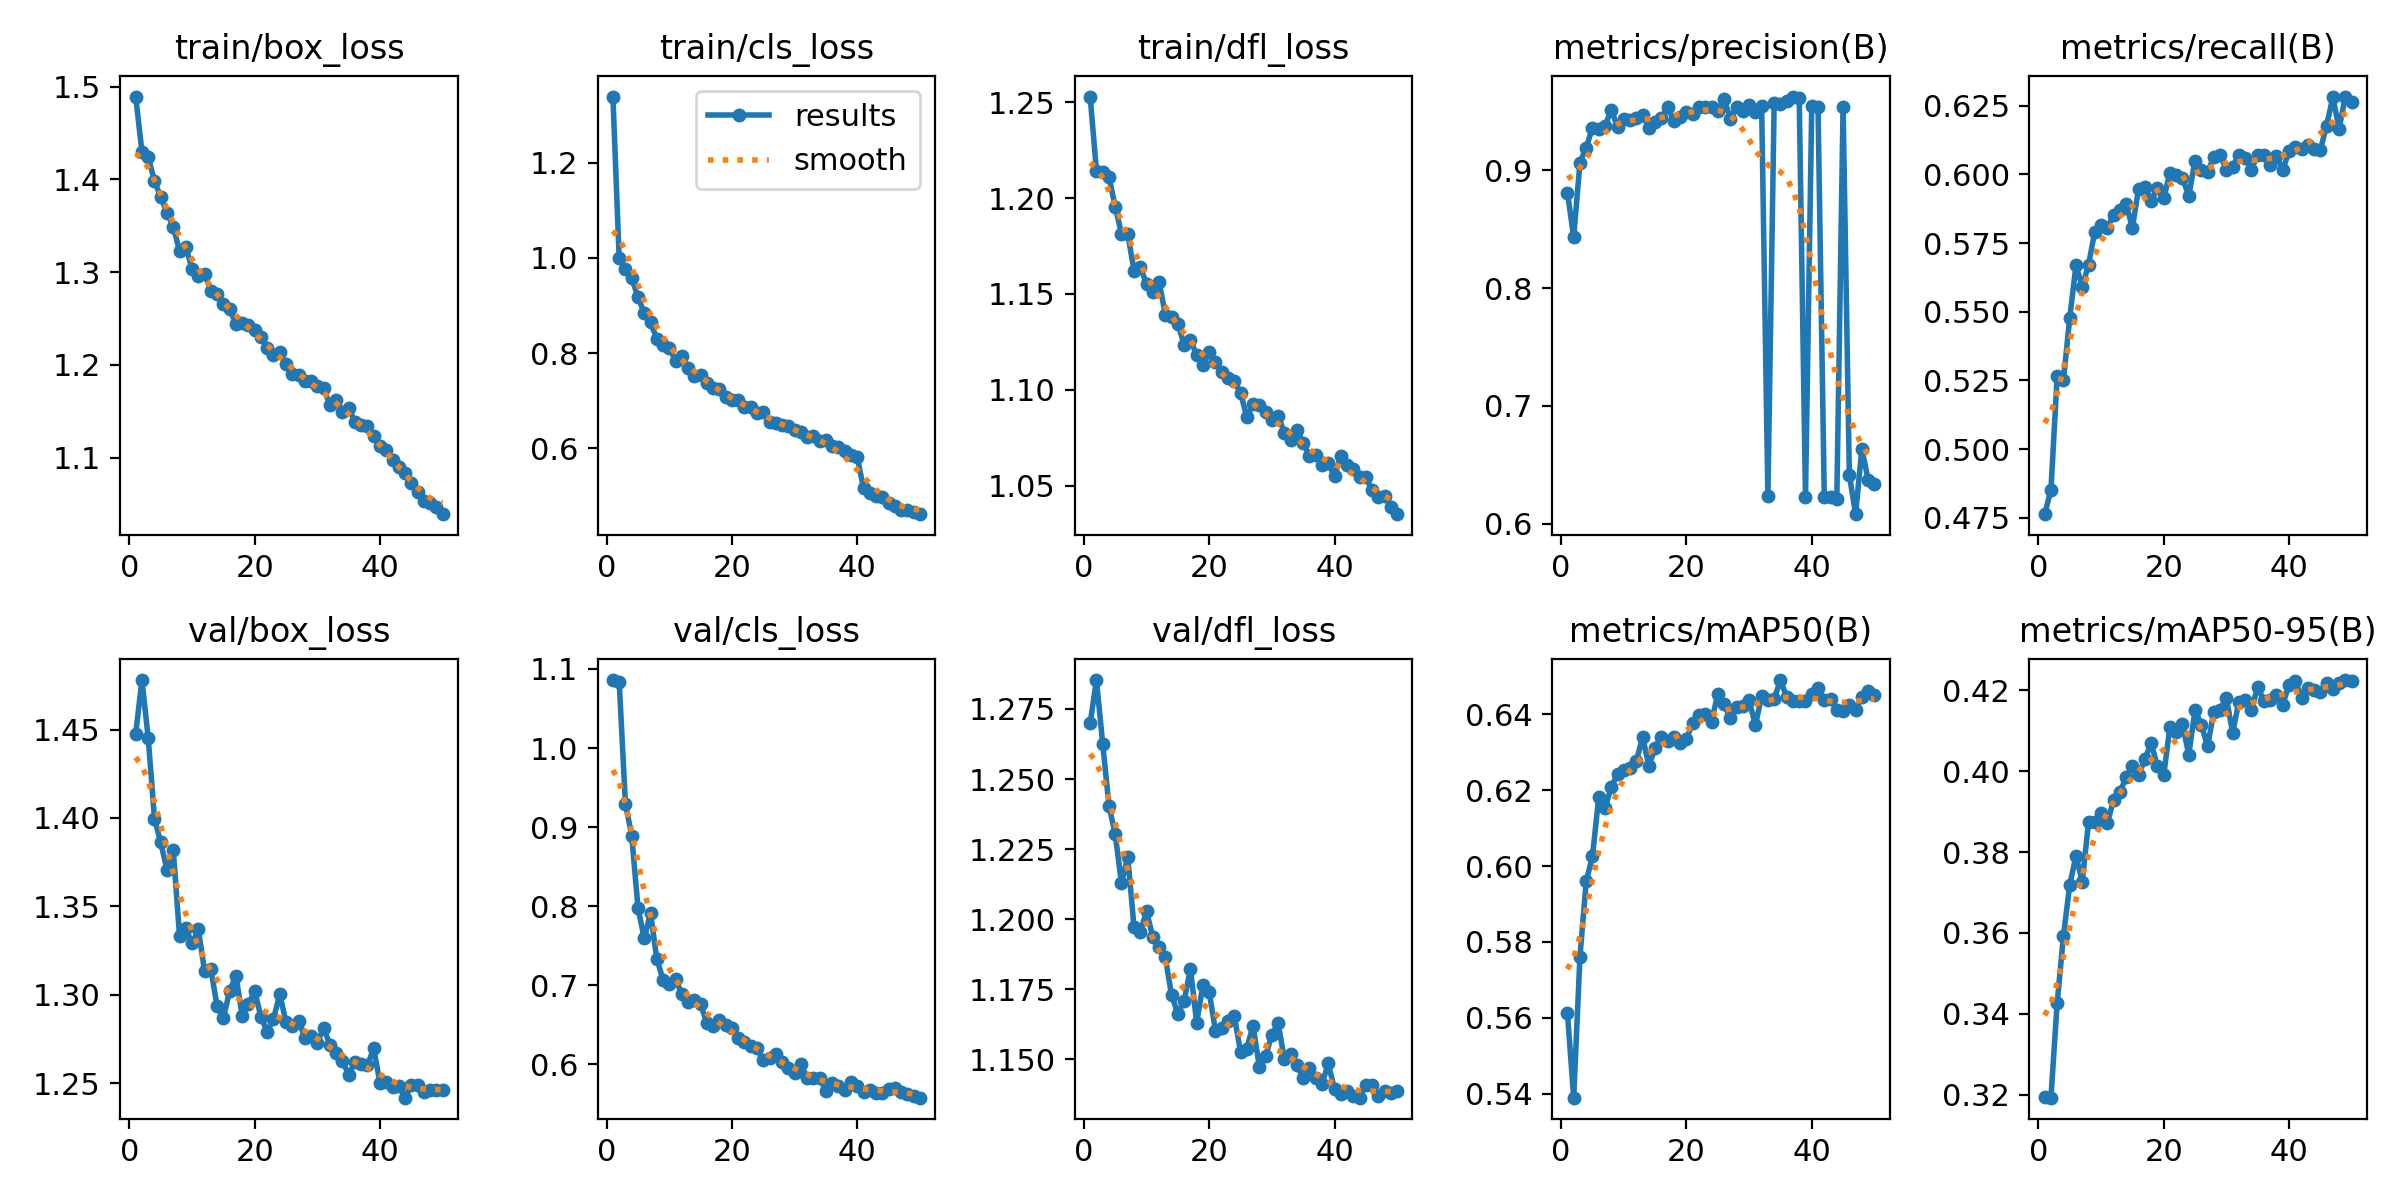

confusion_matrix.png


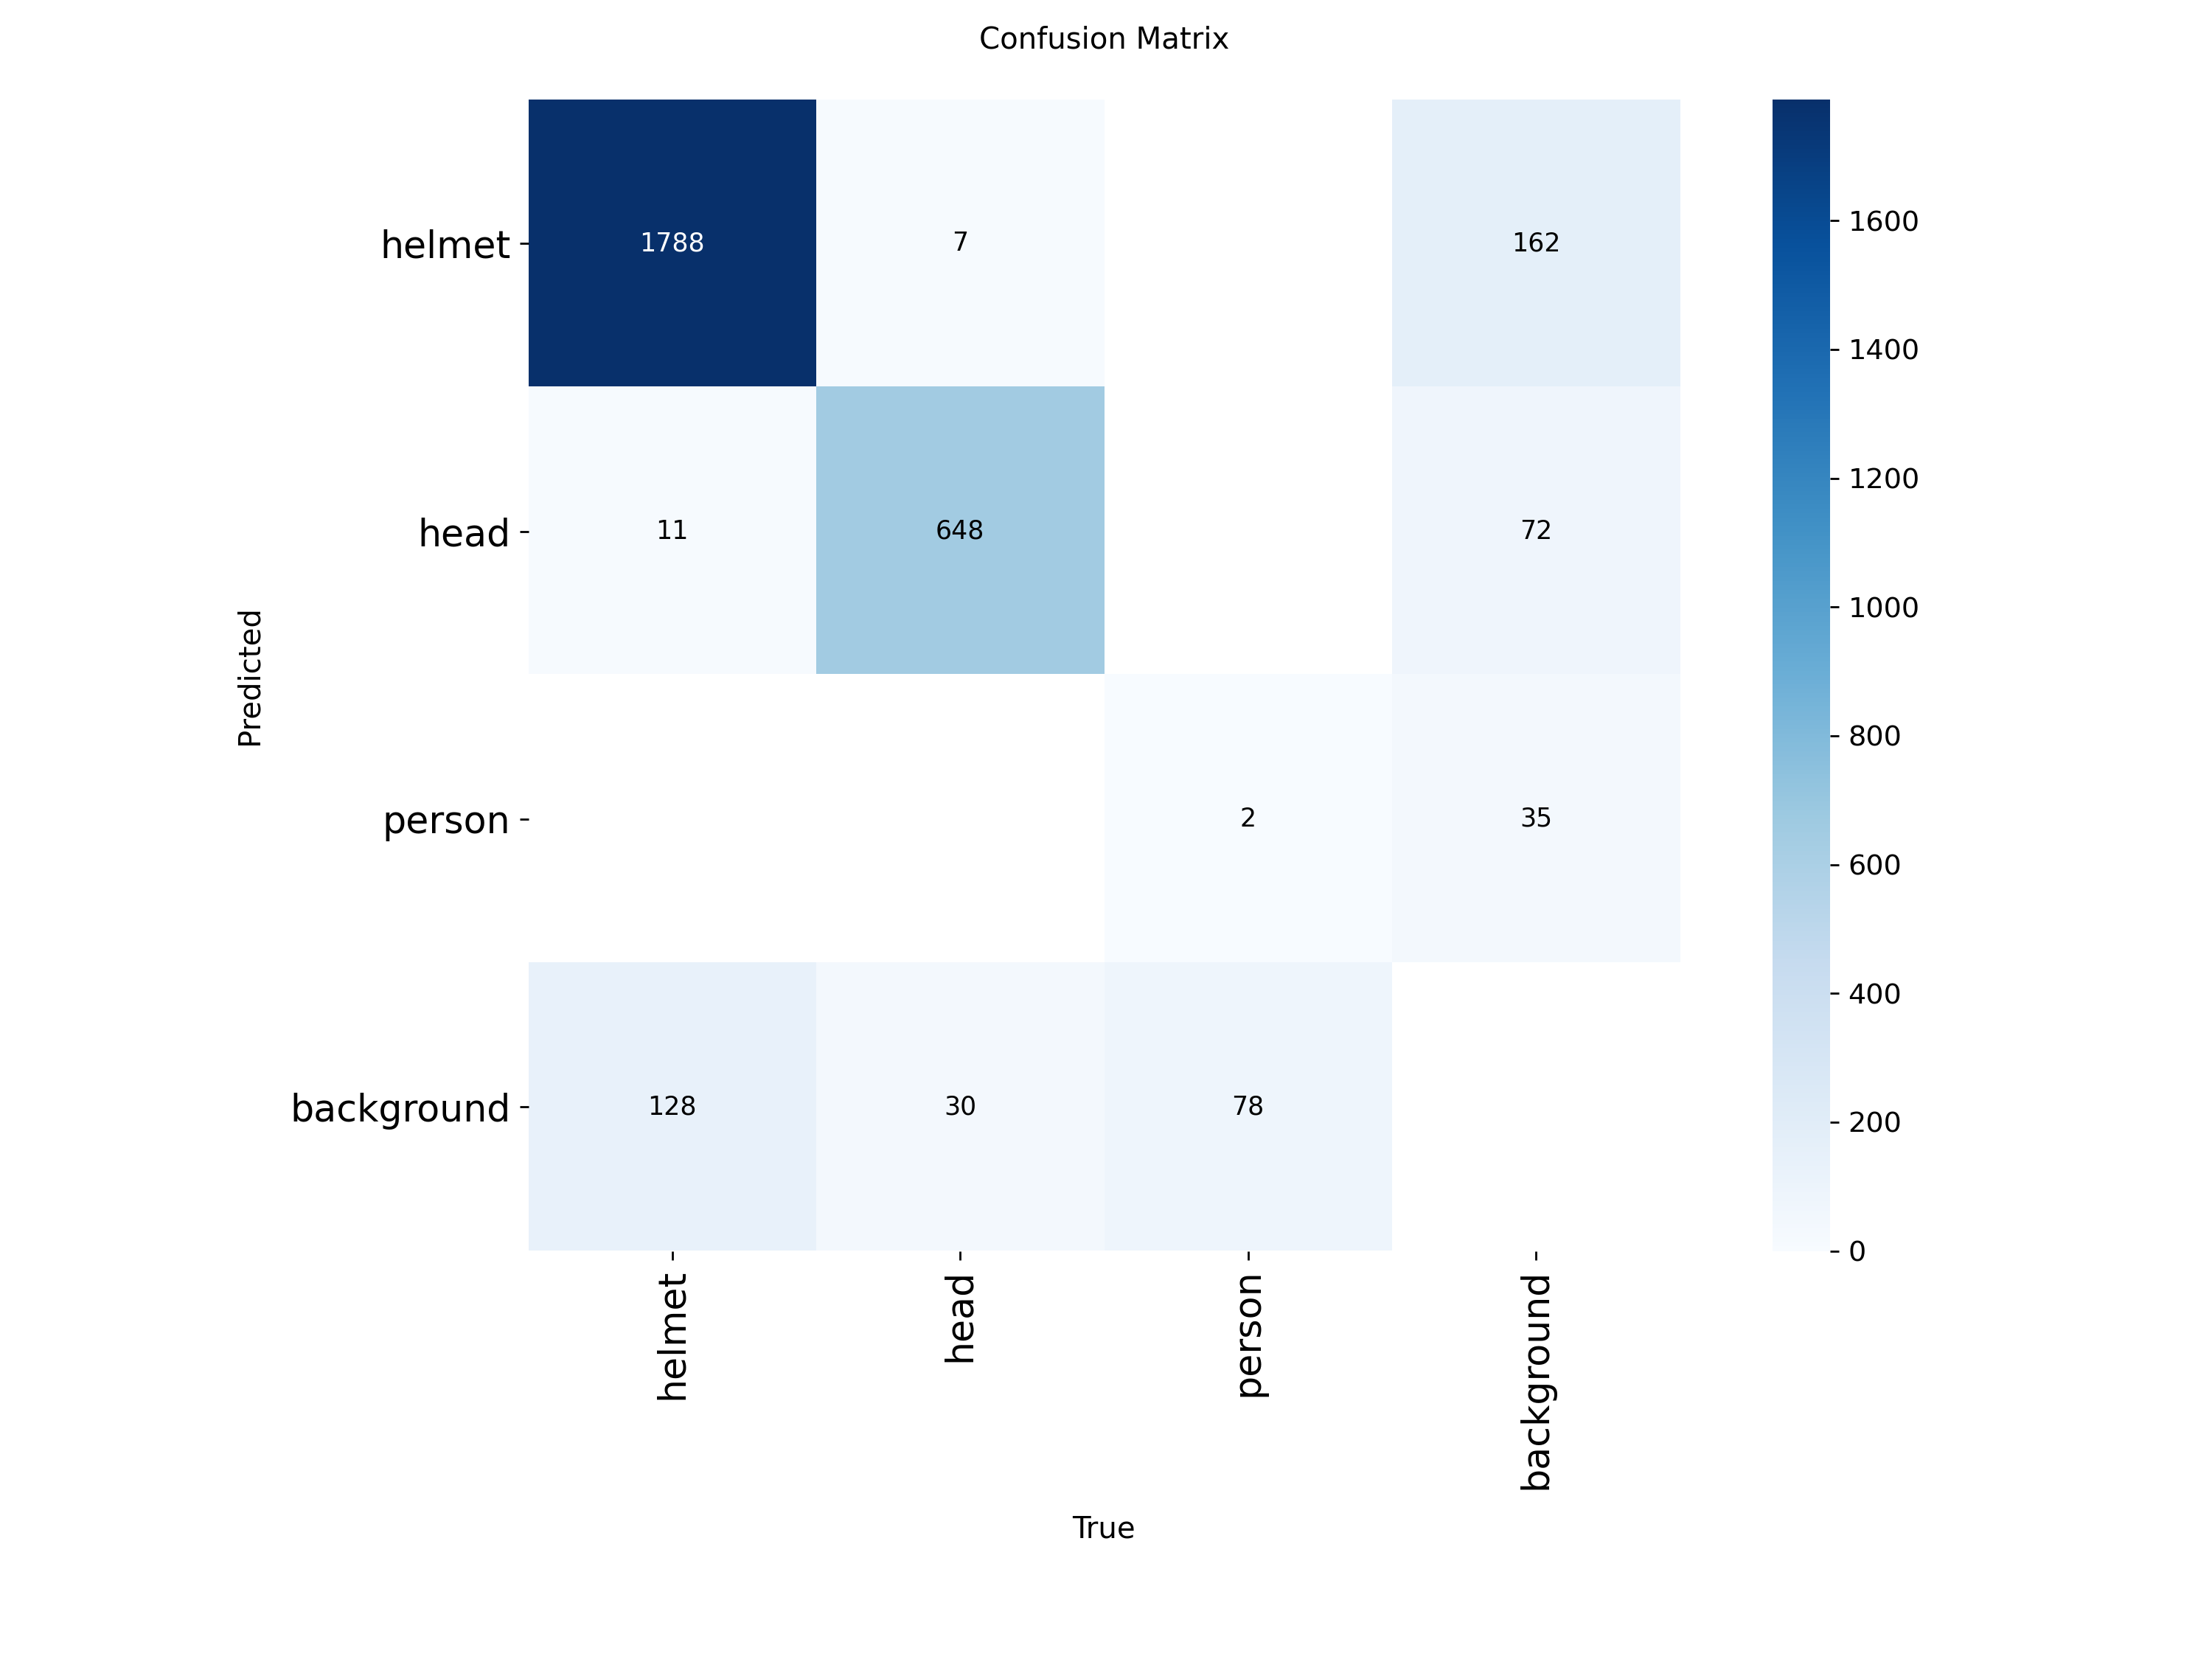

In [10]:
from IPython.display import Image as IPImage, display

run_dir = "runs/detect/hardhat_v1"
for f in ["results.png", "confusion_matrix.png", "PR_curve.png"]:
    p = f"{run_dir}/{f}"
    if os.path.exists(p):
        print(f); display(IPImage(filename=p, width=600))

## 10) Evaluate on test split

In [11]:
metrics = model.val(data="data.yaml", split="test")
print("mAP50    :", round(float(metrics.box.map50), 4))
print("mAP50-95 :", round(float(metrics.box.map), 4))
print("Precision:", round(float(metrics.box.mp), 4))
print("Recall   :", round(float(metrics.box.mr), 4))

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 49.9±43.2 MB/s, size: 250.0 KB)
val: Scanning /content/dataset/labels/test... 500 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 500/500 376.6it/s 1.3s
val: New cache created: /content/dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 2.9it/s 10.9s
                   all        500       2464      0.632      0.595      0.632      0.423
                helmet        459       1882      0.965      0.905      0.959      0.646
                  head         98        526       0.93      0.878      0.929      0.619
                person         13         56          0          0    0.00967    0.00401
Speed: 2.4ms preprocess, 10.5ms inference, 0.0ms loss, 1.6ms postprocess per image
Re

## 11) Visual predictions on test images

In [12]:
best = YOLO("runs/detect/hardhat_v1/weights/best.pt")
results = best.predict(source="dataset/images/test", save=True, conf=0.4)
print("Saved to:", results[0].save_dir)


image 1/500 /content/dataset/images/test/hard_hat_workers1033.png: 640x640 6 helmets, 1 person, 16.1ms
image 2/500 /content/dataset/images/test/hard_hat_workers1034.png: 640x640 10 heads, 16.2ms
image 3/500 /content/dataset/images/test/hard_hat_workers1037.png: 640x640 2 helmets, 16.1ms
image 4/500 /content/dataset/images/test/hard_hat_workers104.png: 640x640 5 heads, 16.1ms
image 5/500 /content/dataset/images/test/hard_hat_workers1079.png: 640x640 14 helmets, 2 heads, 16.1ms
image 6/500 /content/dataset/images/test/hard_hat_workers1106.png: 640x640 5 helmets, 2 heads, 16.1ms
image 7/500 /content/dataset/images/test/hard_hat_workers1120.png: 640x640 11 helmets, 16.1ms
image 8/500 /content/dataset/images/test/hard_hat_workers1125.png: 640x640 6 helmets, 16.1ms
image 9/500 /content/dataset/images/test/hard_hat_workers1141.png: 640x640 5 helmets, 1 head, 16.1ms
image 10/500 /content/dataset/images/test/hard_hat_workers1142.png: 640x640 4 helmets, 16.2ms
image 11/500 /content/dataset/imag

In [13]:
import glob
from IPython.display import Image as IPImage, display

pred_dir = results[0].save_dir
for p in sorted(glob.glob(f"{pred_dir}/*.png"))[:4]:
    display(IPImage(filename=p, width=500))

## 12) (Bonus) Video / webcam

Live webcam (`source=0`) does NOT work in Colab — run it locally.

In [14]:
# Run locally:
# best.predict(source=0, show=True)             # laptop webcam
# best.predict(source="video.mp4", save=True)   # video file
print("Run this locally, not in Colab")

Run this locally, not in Colab


## 13) (Bonus) Streamlit app

Create a separate `app.py` and run `streamlit run app.py`:
```python
import streamlit as st
from ultralytics import YOLO
from PIL import Image

st.title("Hard Hat Detector")
model = YOLO("runs/detect/hardhat_v1/weights/best.pt")

file = st.file_uploader("Upload an image", type=["jpg", "png", "jpeg"])
if file:
    img = Image.open(file)
    results = model.predict(img, conf=0.4)
    st.image(results[0].plot(), caption="Result")
```

## 14) GitHub documentation

README should include: project description, data preparation (VOC→YOLO + folder layout),
training command/config (`yolov8s.pt`, 50 epochs, imgsz 640), metrics table
(mAP / precision / recall) with `results.png` and `confusion_matrix.png`, and prediction images.

Do NOT push the full dataset or large `.pt` files. Add `.gitignore`:
```
dataset/
runs/
*.pt
*.zip
```